In [67]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import torch
from functools import reduce
import itertools

# ==========================
# Reproducibility
# ==========================
np.random.seed(10)

# ==========================
# Global Hyperparameters (same meaning as your code)
# ==========================
L = 1
Nx_u = 3
deg_max = 1          # keep your variable; we will use omega_max as the "effective" cutoff
n_samples = 50

# m = 2
# n_qubits = 2
# L = 1
# Nx_u = 3
# Nx_fit = 3
# deg_max = 1
# blocks = 2
# n_samples = 10

# encoding base (your code uses 3**layer)
BASE = 3

# effective max frequency
omega_max = sum(BASE**l for l in range(L))

# safety: avoid aliasing when accessing +/- frequencies up to omega_max
# assert Nx_u > 2 * omega_max + 1, "Need Nx_u > 2*omega_max+1 to avoid FFT aliasing for +/- frequencies."

# ==========================
# Observable (unchanged definition)
# ==========================
def Observable_local(n, device='cpu', dtype=torch.float32):
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j
    return OL / n

# ==========================
# Helpers: FFT coefficient access with negative frequencies (generalized)
# ==========================
def fft_idx(w, N):
    """Map integer frequency w (can be negative) to numpy FFT index."""
    return w % N

def c_from_fft(c_fft, *w):
    """
    Get c_{(w1,...,wm)} from full mD FFT array.
    Usage:
        c_from_fft(c_fft, w1)          for m=1
        c_from_fft(c_fft, w1, w2)      for m=2
        c_from_fft(c_fft, w1, w2, w3)  for m=3
    """
    idx = tuple(fft_idx(wk, c_fft.shape[k]) for k, wk in enumerate(w))
    return c_fft[idx]

def a_from_fft_cheb(c_fft, nu):
    """
    Compute
        a_nu = sum_{omega : |omega| = nu} c_omega
    using full FFT array.
    General mD: enumerate all sign choices for nonzero components.
    """
    nu = tuple(int(x) for x in nu)
    m = len(nu)

    sign_lists = []
    for k in range(m):
        if nu[k] == 0:
            sign_lists.append([1])
        else:
            sign_lists.append([+1, -1])

    total = 0.0 + 0.0j
    for s in itertools.product(*sign_lists):
        omega = tuple(s[k] * nu[k] for k in range(m))
        total += c_from_fft(c_fft, *omega)
    return total

# ==========================
# Encoding (keep your definition form; now works for any m)
# ==========================
def novel_exp_encoding_multi(x_vec, layer, m):
    for j in range(m):
        phi = x_vec[j]
        coef = BASE ** layer
        qml.RZ(coef * phi, wires=j)

# ==========================
# QFM: compute full mD FFT coefficients (same logic as your m=2)
# ==========================
def qfm_fft_full(weights, circuit_QFM, m):
    u = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f = np.zeros((Nx_u,) * m, dtype=float)

    for idx in np.ndindex((Nx_u,) * m):
        u_vec = np.array([u[i] for i in idx], dtype=float)
        f[idx] = circuit_QFM(u_vec, weights)

    c_fft = np.fft.fftn(f) / (Nx_u**m)
    return c_fft

# ==========================
# Run for m = 1,2,3,... and print mean(var_QCM/var_QFM) over valid freqs up to omega_max
# ==========================
def run_one_m(m):
    n_qubits = m
    blocks = m
    dev = qml.device("default.qubit", wires=n_qubits)

    O_L = Observable_local(n_qubits).numpy()

    @qml.qnode(dev)
    def circuit_QFM(u_vec, weights):
        qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
        for l in range(L):
            novel_exp_encoding_multi(u_vec, l, m)
            qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
        return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

    # store all samples' coefficient tensors on nu-grid [0..omega_max]^m
    shape = (omega_max + 1,) * m
    coeffs_QFM = []
    coeffs_QCM = []
    var_checks = []

    for sample in range(n_samples):
        weights = np.random.uniform(
            0, 2*np.pi,
            size=(L+1, blocks, n_qubits, 3)
        )

        c_fft = qfm_fft_full(weights, circuit_QFM, m)

        # --- build a_nu on grid 0..omega_max ---
        a_cheb = np.zeros(shape, dtype=complex)
        a_fourier = np.zeros(shape, dtype=complex)

        for nu in np.ndindex(shape):
            a_cheb[nu] = a_from_fft_cheb(c_fft, nu)

        for nu in np.ndindex(shape):
            a_fourier[nu] = c_from_fft(c_fft, *nu)


        # keep your naming conventions
        coeffs_QFM.append(a_fourier)
        coeffs_QCM.append(a_cheb)

    coeffs_QFM = np.array(coeffs_QFM)  # (n_samples, ...), complex
    coeffs_QCM = np.array(coeffs_QCM)  # (n_samples, ...), complex

    var_QFM = np.var(coeffs_QFM, axis=0)
    var_QCM = np.var(coeffs_QCM, axis=0)

    # "effective frequency": all nu in [0..omega_max]^m, exclude nu=(0,...,0)
    mask = np.ones(shape, dtype=bool)
    mask[(0,) * m] = False

    denom = var_QFM
    numer = var_QCM
    effective_spectrum = mask

    mean_ratio = float(np.mean(numer[effective_spectrum] / denom[effective_spectrum])) if np.any(effective_spectrum) else np.nan

    result = {
        "m": m,
        "omega_max": omega_max,
        "var_QFM": var_QFM,
        "var_QCM": var_QCM,
        "mean_ratio": mean_ratio,
        "n_effective_freqs": int(np.sum(effective_spectrum)),
        "mean_check_err": float(np.mean(var_checks))
    }
    
    return result

# run
results = []
for m in [1, 2, 3, 4, 5]:
    res = run_one_m(m)
    results.append(res)
    print(m)

1
2
3


KeyboardInterrupt: 

In [57]:
for m in [6,7]:
    res = run_one_m(m)
    results.append(res)
    print(m)

6
7


In [59]:
print("\n=== Diagonal frequency variance ===")

for res in results:
    m = res["m"]
    var_QFM = res["var_QFM"]
    var_QCM = res["var_QCM"]

    nu = (1,) * m

    if all(nu[i] <= omega_max for i in range(m)):
        v_fm = var_QFM[nu]
        v_cm = var_QCM[nu]
 
        print(f"m = {m}")
        # print(f"  nu = {nu}")
        # print(f"  Var_QFM = {v_fm:.6e}")
        # print(f"  Var_QCM = {v_cm:.6e}")
        print(f"  Ratio   = {v_cm / v_fm:.6e}")
        print()


=== Diagonal frequency variance ===
m = 1
  Var_QFM = 1.987203e-02
  Var_QCM = 4.310369e-02
  Ratio   = 2.169063e+00

m = 2
  Var_QFM = 9.840825e-04
  Var_QCM = 4.498910e-03
  Ratio   = 4.571679e+00

m = 3
  Var_QFM = 1.916504e-04
  Var_QCM = 1.129714e-03
  Ratio   = 5.894658e+00

m = 4
  Var_QFM = 9.043354e-06
  Var_QCM = 1.865436e-04
  Ratio   = 2.062770e+01

m = 5
  Var_QFM = 2.740439e-06
  Var_QCM = 6.277982e-05
  Ratio   = 2.290867e+01

m = 6
  Var_QFM = 2.297398e-07
  Var_QCM = 7.736574e-06
  Ratio   = 3.367538e+01

m = 7
  Var_QFM = 1.311623e-08
  Var_QCM = 2.680355e-06
  Ratio   = 2.043541e+02


m = 1, Ratio = 2.169063e+00
m = 2, Ratio = 4.571679e+00
m = 3, Ratio = 5.894658e+00
m = 4, Ratio = 2.062770e+01
m = 5, Ratio = 2.290867e+01
m = 6, Ratio = 3.367538e+01
m = 7, Ratio = 2.043541e+02


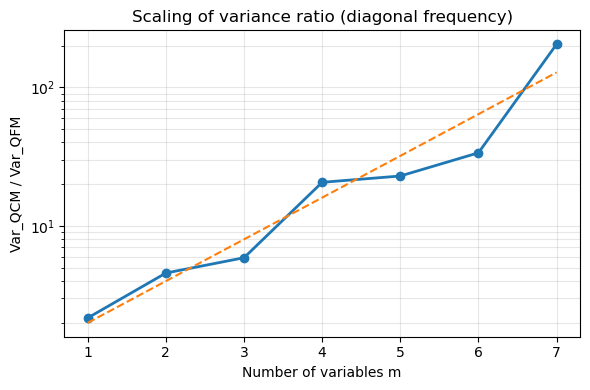

In [63]:
ms = []
ratios = []

for res in results:
    m = res["m"]
    var_QFM = res["var_QFM"]
    var_QCM = res["var_QCM"]

    nu = (1,) * m

    if all(nu[i] <= omega_max for i in range(m)):
        v_fm = var_QFM[nu]
        v_cm = var_QCM[nu]

        ratio = float(v_cm / v_fm)

        ms.append(m)
        ratios.append(ratio)

        print(f"m = {m}, Ratio = {ratio:.6e}")

import matplotlib.pyplot as plt
import numpy as np

ms = np.array(ms)
ratios = np.array(ratios)

plt.figure(figsize=(6,4))

plt.plot(ms, ratios, 'o-', linewidth=2, markersize=6)
plt.plot(ms, 2**ms, '--', label="2^m reference")
plt.yscale("log")   # ⭐ 非常重要（指数增长必须用log）

plt.xlabel("Number of variables m")
plt.ylabel("Var_QCM / Var_QFM")

plt.grid(True, which="both", alpha=0.3)
plt.title("Scaling of variance ratio (diagonal frequency)")
plt.tight_layout()
plt.show()

In [16]:
np.save("results.npy", results, allow_pickle=True)

In [17]:
results = np.load("results.npy", allow_pickle=True)

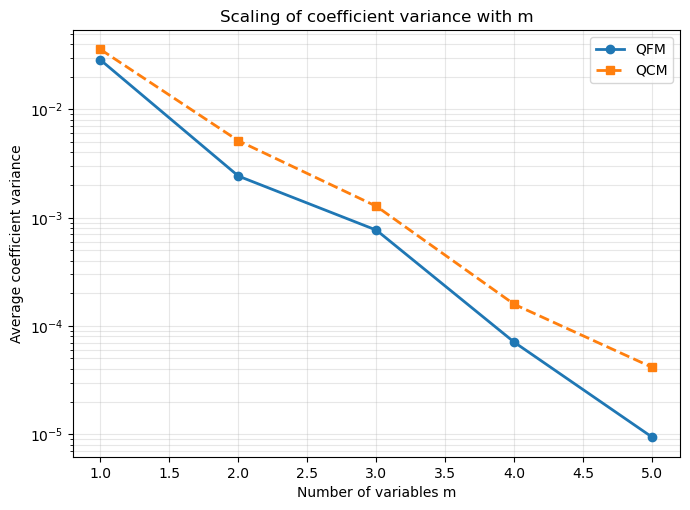

In [20]:
ms = []
avg_var_QFM = []
avg_var_QCM = []

for r in results:
    ms.append(r["m"])
    avg_var_QFM.append(np.mean(r["var_QFM"]))
    avg_var_QCM.append(np.mean(r["var_QCM"]))

ms = np.array(ms)
avg_var_QFM = np.array(avg_var_QFM)
avg_var_QCM = np.array(avg_var_QCM)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(ms, avg_var_QFM, 'o-', linewidth=2, markersize=6, label="QFM")
plt.plot(ms, avg_var_QCM, 's--', linewidth=2, markersize=6, label="QCM")

plt.yscale("log")   # ⭐ 指数y轴

plt.xlabel("Number of variables m")
plt.ylabel("Average coefficient variance")

plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.title("Scaling of coefficient variance with m")

plt.show()

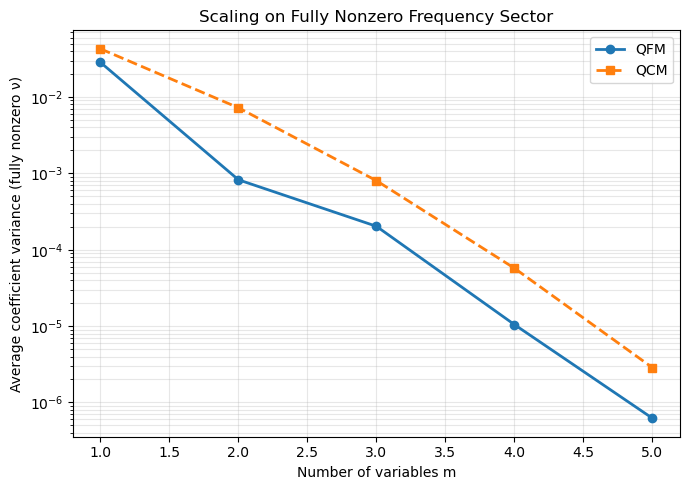

In [21]:
ms = []
avg_var_QFM = []
avg_var_QCM = []

for r in results:
    m = r["m"]
    var_QFM = r["var_QFM"]
    var_QCM = r["var_QCM"]

    # --- 构造 fully-nonzero mask ---
    shape = var_QFM.shape
    mask = np.ones(shape, dtype=bool)

    # 对每个轴，把 index=0 的那一整层去掉
    for axis in range(len(shape)):
        idx = [slice(None)] * len(shape)
        idx[axis] = 0
        mask[tuple(idx)] = False

    # 只在 fully-nonzero 频率上取平均
    avg_var_QFM.append(np.mean(var_QFM[mask]))
    avg_var_QCM.append(np.mean(var_QCM[mask]))
    ms.append(m)

ms = np.array(ms)
avg_var_QFM = np.array(avg_var_QFM)
avg_var_QCM = np.array(avg_var_QCM)

plt.figure(figsize=(7,5))

plt.semilogy(ms, avg_var_QFM, 'o-', linewidth=2, markersize=6, label="QFM")
plt.semilogy(ms, avg_var_QCM, 's--', linewidth=2, markersize=6, label="QCM")

plt.xlabel("Number of variables m")
plt.ylabel("Average coefficient variance (fully nonzero ν)")
plt.title("Scaling on Fully Nonzero Frequency Sector")

plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [34]:
var_QFM.shape

(2, 2, 2, 2)

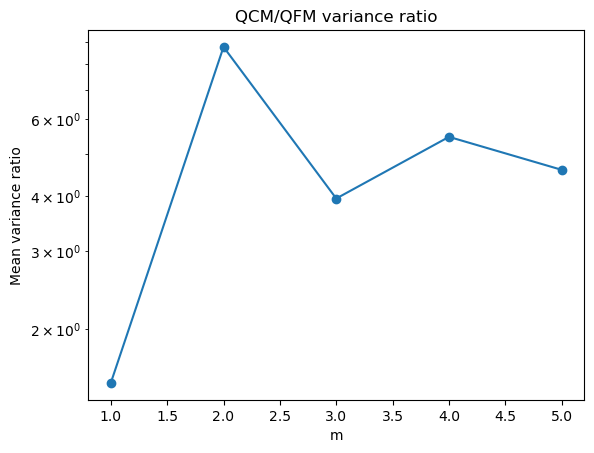

In [22]:
ratios = []

for r in results:
    var_QFM = r["var_QFM"]
    var_QCM = r["var_QCM"]

    mask = np.ones_like(var_QFM, dtype=bool)
    for axis in range(var_QFM.ndim):
        idx = [slice(None)] * var_QFM.ndim
        idx[axis] = 0
        mask[tuple(idx)] = False

    ratio = np.mean(var_QCM[mask] / var_QFM[mask])
    ratios.append(ratio)

plt.figure()
plt.semilogy(ms, ratios, 'o-')
plt.xlabel("m")
plt.ylabel("Mean variance ratio")
plt.title("QCM/QFM variance ratio")
plt.show()

In [66]:
import numpy as np
import pennylane as qml
import torch
import itertools

np.random.seed(10)
torch.manual_seed(10)

# ======================
# Hyperparameters
# ======================
L = 1
BASE = 3
n_samples = 50

omega_max = sum(BASE**l for l in range(L))
Nx = 2 * omega_max + 1  # minimal Nyquist grid

# ======================
# Observable (FIXED)
# ======================
def Observable_local(n):
    P0 = torch.tensor([[1., 0.],[0., 0.]])
    I2 = torch.eye(2)

    OL = torch.zeros((2**n, 2**n))

    for j in range(n):
        op = torch.ones(1)  # <-- FIX HERE
        for k in range(n):
            op = torch.kron(op, P0 if k == j else I2)
        OL += op

    return OL / n

# ======================
# Frequency list
# ======================
def frequency_list(m):
    freqs = list(itertools.product(range(-omega_max, omega_max+1), repeat=m))
    freqs.remove((0,) * m)
    return np.array(freqs)

# ======================
# Encoding
# ======================
def encoding(u_vec, layer, m):
    for j in range(m):
        qml.RZ((BASE**layer) * u_vec[j], wires=j)

# ======================
# Main variance computation
# ======================
def compute_variance(m):

    dev = qml.device("default.qubit", wires=m)
    O_L = Observable_local(m)

    @qml.qnode(dev, interface="torch")
    def circuit(u_vec, weights):

        qml.templates.StronglyEntanglingLayers(weights[0], wires=range(m))

        for l in range(L):
            encoding(u_vec, l, m)
            qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(m))

        return qml.expval(qml.Hermitian(O_L, wires=range(m)))

    # sampling grid
    u_vals = np.linspace(0, 2*np.pi, Nx, endpoint=False)
    grid = np.array(list(itertools.product(u_vals, repeat=m)))  # shape (Nx^m, m)

    freqs = frequency_list(m)
    n_freq = len(freqs)

    coeff_samples = np.zeros((n_samples, n_freq), dtype=complex)

    for s in range(n_samples):

        weights = torch.tensor(
            np.random.uniform(0, 2*np.pi, size=(L+1, m, m, 3)),
            dtype=torch.float32
        )

        # evaluate circuit
        f_vals = np.array([
            circuit(torch.tensor(u, dtype=torch.float32), weights).item()
            for u in grid
        ])

        # vectorized phase computation
        phase_matrix = np.exp(1j * grid @ freqs.T)  # (Nx^m, n_freq)

        coeff_samples[s] = (f_vals @ phase_matrix) / (Nx**m)

    var = np.var(coeff_samples, axis=0)

    return np.mean(var)

# ======================
# Run
# ======================
for m in [1,2,3,4]:
    mean_var = compute_variance(m)
    print(f"m={m}, mean coefficient variance = {mean_var}")

m=1, mean coefficient variance = 0.019872033000366537
m=2, mean coefficient variance = 0.0021417679925956543
m=3, mean coefficient variance = 0.00030807011731205587


KeyboardInterrupt: 